
![](img/logoitqv1.jpg)

##  01PAO26-26 - Python 1, # 3_2_2_transformaciones

![](img/python_logo.png)

*Alysson Guaman *

**Repositorio:** [Github](https://github.com/a12lj/machine-learning.git)

Image dimensions:  (256, 256, 3)


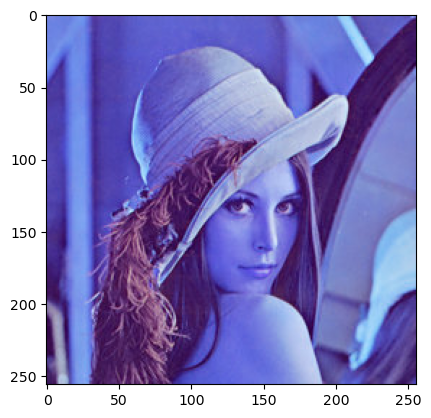

In [1]:
# READ AN IMAGE
# pip install opencv-python o conda install opencv-python
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('images/images/Lena_RGB.png')
print('Image dimensions: ', np.shape(img))
plt.imshow(img, cmap='gray')
plt.show()

In [7]:
# Extraer por separado la imagen de grises de cada canal
R = img[:,:,2]
G = img[:,:,1]
B = img[:,:,0]

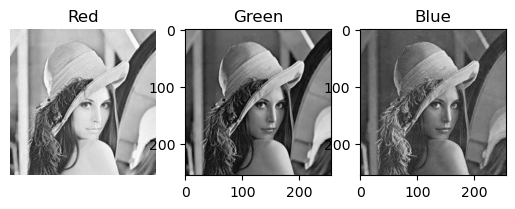

In [8]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red'), ax[0].axis('off')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()

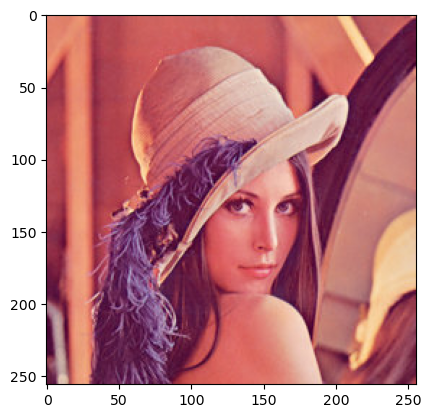

In [9]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()

### TRANSFORMACIONES DE INTENSIDAD

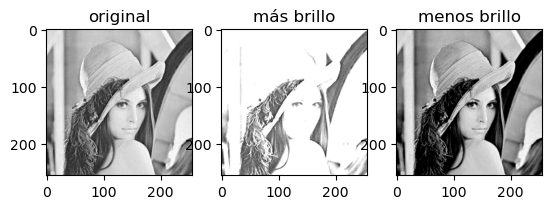

In [10]:
# CAMBIO DE BRILLO
img = cv2.imread('images/images/Lena_RGB.png')
img = img[:,:,2] # red color
mas_brillo = 100
menos_brillo = -100

mas_brillo_img = cv2.add(img, mas_brillo) # Importante el "cv2.add" en vez de "+"
menos_brillo_img = cv2.add(img, menos_brillo)

fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()

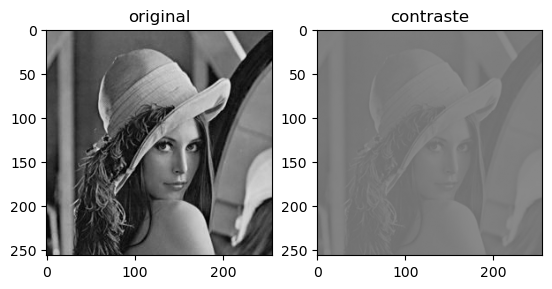

In [11]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread('images/images/Lena_RGB.png')
img = img[:,:,1] # canal verde
contraste = -100
f = 131*(contraste + 127)/(127*(131-contraste))
alpha_c = f
gamma_c = 127*(1-f)
contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste')
plt.show()

### CONVERSIONES DEL ESPACIO DE COLOR

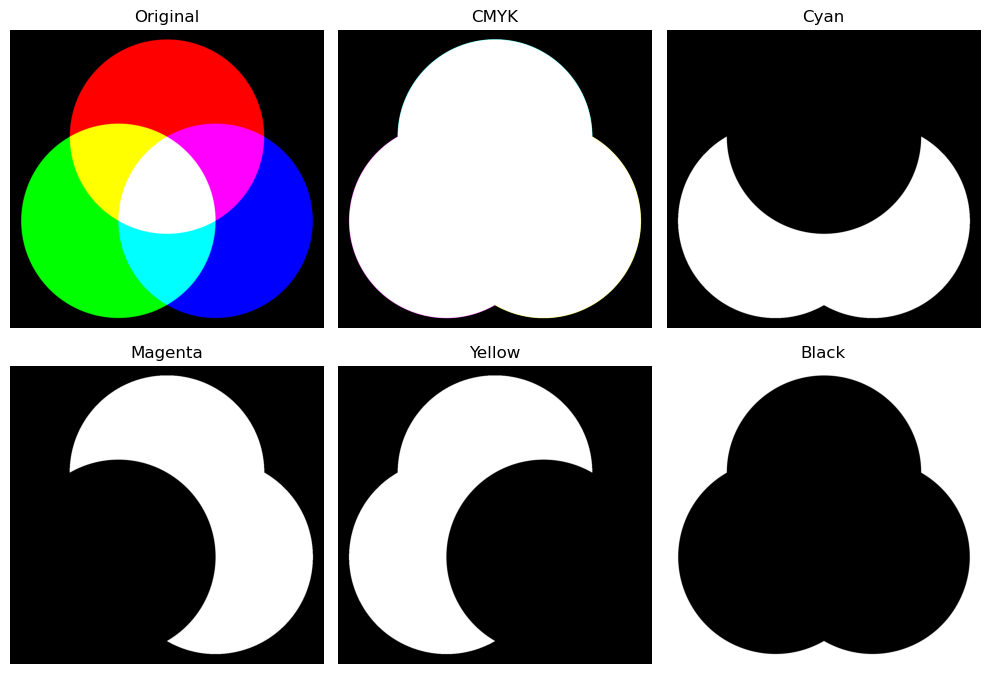

In [23]:
# RGB to CMYK

import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io

# Leer imagen
img = io.imread('images/images/colores.png')   # Cambia la ruta si es necesario

# Normalizar la imagen entre 0 y 1
rgb = img.copy()
rgb_p = rgb.astype(np.float32) / 255.0

# Separar canales RGB
R = rgb_p[:, :, 0]
G = rgb_p[:, :, 1]
B = rgb_p[:, :, 2]

# Calcular canal K
with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)

    # Calcular canales C, M y Y
    C = (1 - R - K) / (1 - K)
    M = (1 - G - K) / (1 - K)
    Y = (1 - B - K) / (1 - K)

# Reemplazar NaN por 0
C = np.nan_to_num(C)
M = np.nan_to_num(M)
Y = np.nan_to_num(Y)
K = np.nan_to_num(K)

# Convertir a imagen de 8 bits
CMYK = (np.dstack((C, M, Y, K)) * 255).astype(np.uint8)

# Separar canales
C, M, Y, K = cv2.split(CMYK)

# Mostrar resultados
fig, ax = plt.subplots(2, 3, figsize=(10, 7))

ax[0,0].imshow(img)
ax[0,0].set_title("Original")
ax[0,0].axis("off")

ax[0,1].imshow(CMYK)
ax[0,1].set_title("CMYK")
ax[0,1].axis("off")

ax[0,2].imshow(C, cmap="gray")
ax[0,2].set_title("Cyan")
ax[0,2].axis("off")

ax[1,0].imshow(M, cmap="gray")
ax[1,0].set_title("Magenta")
ax[1,0].axis("off")

ax[1,1].imshow(Y, cmap="gray")
ax[1,1].set_title("Yellow")
ax[1,1].axis("off")

ax[1,2].imshow(K, cmap="gray")
ax[1,2].set_title("Black")
ax[1,2].axis("off")

plt.tight_layout()
plt.show()

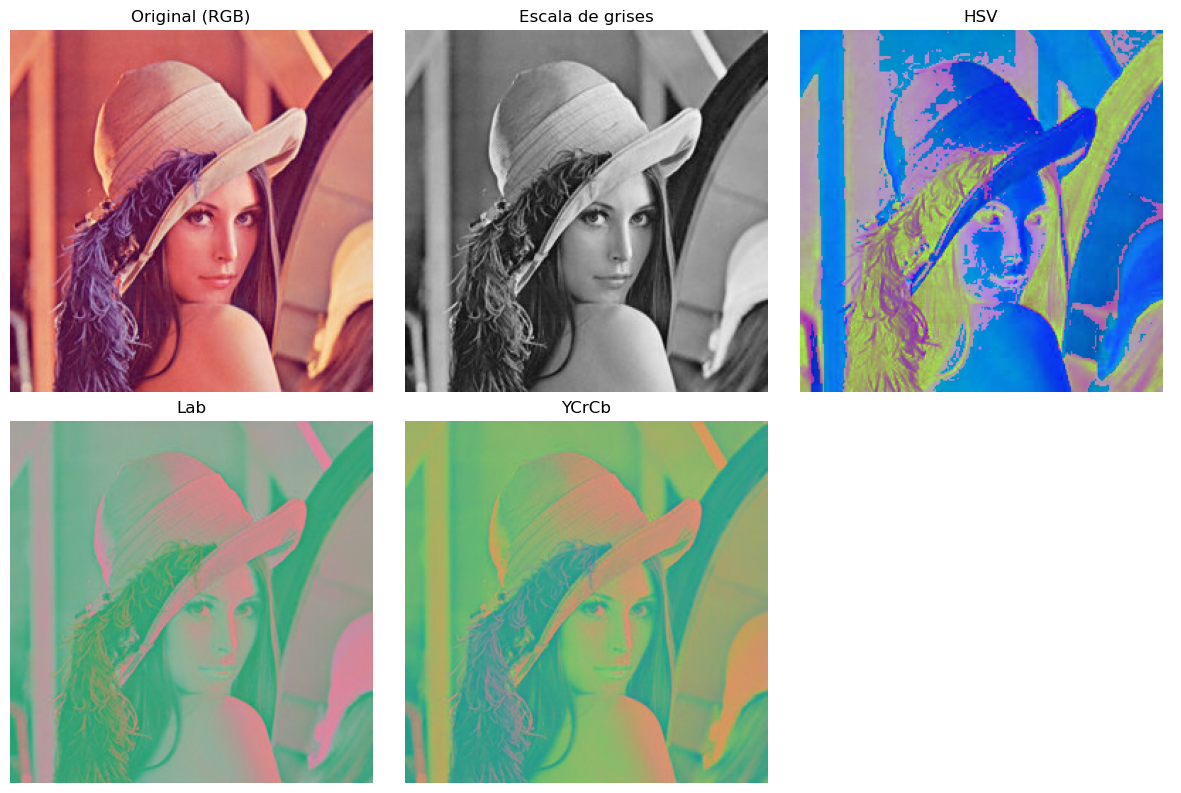

In [26]:
import cv2
import matplotlib.pyplot as plt
from skimage import io

# Leer imagen
img = cv2.imread('images/images/Lena_RGB.png')

# Verificar que la imagen se cargó correctamente
if img is None:
    print("No se pudo cargar la imagen.")
else:
    # Conversión de espacios de color
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
    YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

    # OpenCV lee en BGR, convertir a RGB para mostrar correctamente
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar imágenes
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))

    ax[0,0].imshow(img_rgb)
    ax[0,0].set_title("Original (RGB)")
    ax[0,0].axis("off")

    ax[0,1].imshow(gray_img, cmap='gray')
    ax[0,1].set_title("Escala de grises")
    ax[0,1].axis("off")

    ax[0,2].imshow(HSV)
    ax[0,2].set_title("HSV")
    ax[0,2].axis("off")

    ax[1,0].imshow(Lab)
    ax[1,0].set_title("Lab")
    ax[1,0].axis("off")

    ax[1,1].imshow(YCrCb)
    ax[1,1].set_title("YCrCb")
    ax[1,1].axis("off")

    ax[1,2].axis("off")

    plt.tight_layout()
    plt.show()

### TRANSFORMACIONES GEOMÉTRICAS

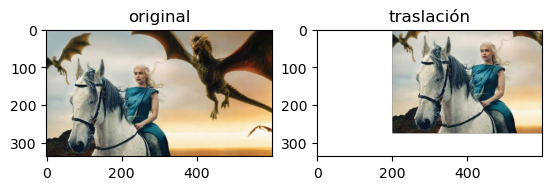

In [15]:
# TRASLACIÓN
img = io.imread('images/images/GOT.png')
rows, cols, ch = img.shape
M = np.float32([[1,0,200],[0,1,-60]]) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()

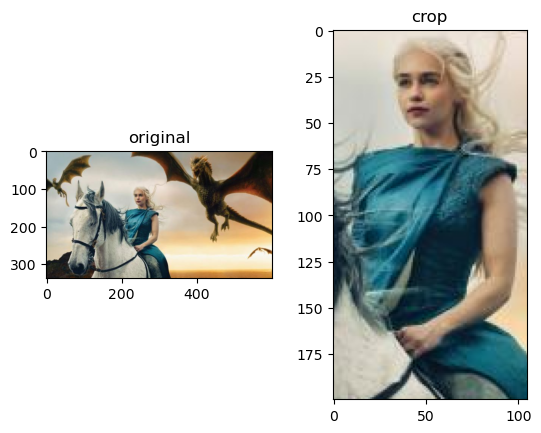

In [16]:
# CROPPING
img = io.imread('images/images/GOT.png')
new_img = img[90:290, 200:305]

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

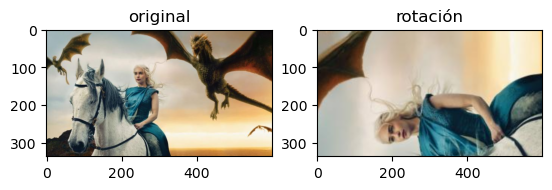

In [17]:
# ROTACIÓN
img = io.imread('images/images/GOT.png')
rows, cols, ch = img.shape
M = cv2.getRotationMatrix2D((cols/2,rows/2),angle=90,scale=2) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()

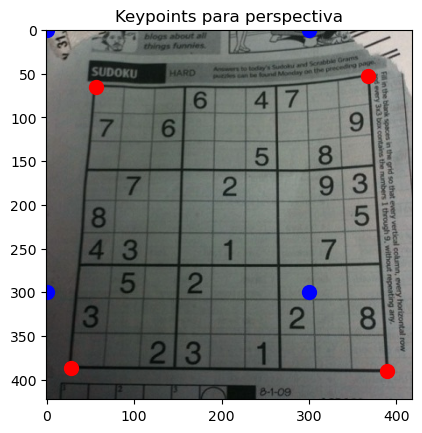

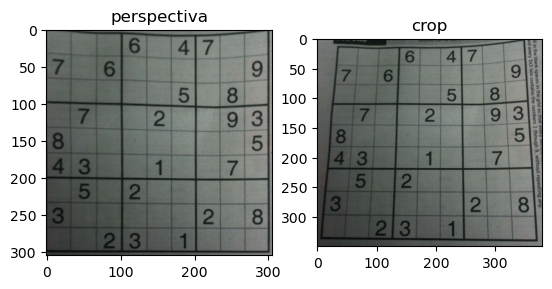

In [18]:
# PERSPECTIVA
img = cv2.imread('images/images/sudoku.png')
rows, cols, ch = img.shape
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

plt.imshow(img, cmap='gray')
for i in range(0,4):
    plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=10)
    plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=10)
plt.title('Keypoints para perspectiva')
plt.show()

M = cv2.getPerspectiveTransform(pts1,pts2) # Defino la matriz de transformación
pers = cv2.warpPerspective(img,M,(305,305)) # Aplico la transformación
crop = img[50:400,20:400]

figs, ax = plt.subplots(1,2)
ax[0].imshow(pers, cmap='gray'), ax[0].set_title('perspectiva')
ax[1].imshow(crop, cmap='gray'), ax[1].set_title('crop')
plt.show()

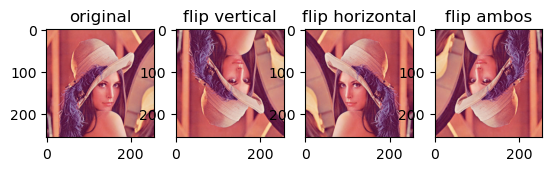

In [19]:
# FLIPPING
# Leer la imagen "Lena_RGB.png" en formato RGB
img = io.imread('images/images/Lena_RGB.png')
# Voltear la imagen para conseguir las siguientes transformaciones. Utiliza el método "cv2.flip()"
flipVertical = cv2.flip(img,0)
flipHorizontal = cv2.flip(img,1)
flipBoth = cv2.flip(img,-1)

figs, ax = plt.subplots(1,4)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(flipVertical, cmap='gray'), ax[1].set_title('flip vertical')
ax[2].imshow(flipHorizontal, cmap='gray'), ax[2].set_title('flip horizontal')
ax[3].imshow(flipBoth, cmap='gray'), ax[3].set_title('flip ambos')
plt.show()